In [ ]:
# Fig 7B Layer 4 LFP mean for sync vs asyn, onset and sustained, forepaw and hindpaw S1

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import os
import pickle
import matplotlib
import matplotlib.pyplot as plt
from scipy import stats
import pingouin as pg

%matplotlib inline

matplotlib.rcParams['font.size'] = 7
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['font.sans-serif'] = 'Arial'

In [ ]:
dir = os.getcwd()
base_dir = os.path.dirname(dir)
data_dir = os.path.join(base_dir, 'data')

In [4]:
# load mean lfp data
lfp_mean_groups_file = os.path.join(data_dir,'lfp_mean_groups.pickle')

with open(lfp_mean_groups_file, 'rb') as handle:
     lfp_mean_groups = pickle.load(handle)


In [5]:
allgroups = ['TrkC','TrkB', 'TrkC_S1HP', 'TrkB_S1HP']

male_list = ['BRC2','BRC5','BRN5','BTT1','BTT3','BPO5','BPU4','BQD3','BTK4','BTM2','BTM3']
female_list = ['BQQ4','BRD2','BRO3','BRO4','BUF4','BPP1','BPV4','BPV5','BQE3','BTN4','BTR5']

sex_map = {name: 'Male' for name in male_list}
sex_map.update({name: 'Female' for name in female_list})


In [6]:
# recordings in each group TrkC/TrkB/TrkC_S1HP/TrkB_S1HP

def get_recording_list(recording_group):
    if recording_group == 'TrkC':
        recordingID_list = ['251005_BQQ4_day1','251006_BQQ4_day2','251007_BQQ4_day3','251012_BRD2_day1','251012_BRC2_day1',
                            '251013_BRD2_day2','251013_BRC2_day2','251013_BRC5_day2','251027_BRN5_day1','251027_BRO4_day1',
                            '251028_BRO4_day2','260304_BTT3_day7','260304_BRO3_day7'] # TrkC with additional 2 files

    elif recording_group == 'TrkB':
        recordingID_list = ['250823_BPP1_day2','250824_BPU4_day1','250825_BPO5_day2','250825_BPU4_day2','250912_BPV4_day1',
                            '250912_BQE3_day1','250913_BPV4_day2','250914_BQD3_day2','250914_BQE3_day3','250915_BPV5_day2',] # TrkB

    elif recording_group == 'TrkC_S1HP':
        recordingID_list = ['260216_BTT1_day3','260221_BUF4_day2', '260227_BTT3_day2','260228_BRO3_day3'] # TrkC S1 HP

    elif recording_group == 'TrkB_S1HP':  
        recordingID_list = ['260218_BTR5_day1','260218_BTM2_day1','260220_BTN4_day1','260221_BTK4_day2','260226_BTM3_day1'] # TrkB S1 HP

    elif recording_group == 'TrkC_add':
        recordingID_list = ['260304_BTT3_day7','260304_BRO3_day7'] # TrkC S1 FP additional data

    return recordingID_list

In [7]:
# organize into df - for each layer
layer_group = ['l23','l4','l5','l6']

mlfp_on_layers = {}
mlfp_sus_layers = {}
mlfp_diff_layers = {}

mlfp_on_alllayers_df = pd.DataFrame(columns=['recID','genoGroup','condSync','mlfp','layer'])
mlfp_sus_alllayers_df = pd.DataFrame(columns=['recID','genoGroup','condSync','mlfp','layer'])
mlfp_diff_alllayers_df = pd.DataFrame(columns=['recID','genoGroup','diffSyncON','diffSyncSUS','layer'])

for ilayer in range(3): # use first 3 - 'l23','l4','l5'
    ilayer_name = layer_group[ilayer]
    ilayer_mlfp_on = pd.DataFrame(columns=['recID','genoGroup','condSync','mlfp'])
    ilayer_mlfp_sus = pd.DataFrame(columns=['recID','genoGroup','condSync','mlfp'])
    ilayer_mlfp_diff = pd.DataFrame(columns=['recID','genoGroup','diffSyncON','diffSyncSUS'])

    for recording_group in allgroups:
        recordingID_list = get_recording_list(recording_group)

        lfp_dict = lfp_mean_groups[recording_group]

        lfp_on = lfp_dict['lfp_on_rmbase'] # use not-normalized data
        lfp_sus = lfp_dict['lfp_sus_rmbase']

        lfp_on_ilayer = lfp_on[:,:,ilayer]
        lfp_sus_ilayer = lfp_sus[:,:,ilayer]
        
        lfp_on_ilayer_df = pd.DataFrame(lfp_on_ilayer, columns=['sync','async'])
        lfp_sus_ilayer_df = pd.DataFrame(lfp_sus_ilayer, columns=['sync','async'])

        lfp_on_ilayer_df['genoGroup'] = recording_group
        lfp_sus_ilayer_df['genoGroup'] = recording_group

        lfp_on_ilayer_df['recID'] = recordingID_list
        lfp_sus_ilayer_df['recID'] = recordingID_list

        lfp_diff_ilayer_df = lfp_on_ilayer_df[['recID','genoGroup']].copy()
        lfp_diff_ilayer_df['diffSyncON'] =  lfp_on_ilayer_df['sync'] - lfp_on_ilayer_df['async']
        lfp_diff_ilayer_df['diffSyncSUS'] = lfp_sus_ilayer_df['sync'] - lfp_sus_ilayer_df['async']
        
        lfp_on_ilayer_df_melted = lfp_on_ilayer_df.melt(
            id_vars=['recID'], 
            value_vars=['sync', 'async'], 
            var_name='condSync', 
            value_name='mlfp'
            )
        
        lfp_sus_ilayer_df_melted = lfp_sus_ilayer_df.melt(
            id_vars=['recID'], 
            value_vars=['sync', 'async'], 
            var_name='condSync', 
            value_name='mlfp'
            )
        
        lfp_on_ilayer_df_melted['genoGroup'] = recording_group
        lfp_sus_ilayer_df_melted['genoGroup'] = recording_group
        
        ilayer_mlfp_on = pd.concat([ilayer_mlfp_on,lfp_on_ilayer_df_melted],ignore_index=True)
        ilayer_mlfp_sus = pd.concat([ilayer_mlfp_sus,lfp_sus_ilayer_df_melted],ignore_index=True)
        ilayer_mlfp_diff = pd.concat([ilayer_mlfp_diff, lfp_diff_ilayer_df],ignore_index=True)

    ilayer_mlfp_on['layer'] = ilayer_name
    ilayer_mlfp_sus['layer'] = ilayer_name
    ilayer_mlfp_diff['layer'] = ilayer_name

    mlfp_on_layers[ilayer_name] = ilayer_mlfp_on
    mlfp_sus_layers[ilayer_name] = ilayer_mlfp_sus
    mlfp_diff_layers[ilayer_name] = ilayer_mlfp_diff

    mlfp_on_alllayers_df = pd.concat([mlfp_on_alllayers_df, ilayer_mlfp_on])
    mlfp_sus_alllayers_df = pd.concat([mlfp_sus_alllayers_df, ilayer_mlfp_sus])
    mlfp_diff_alllayers_df = pd.concat([mlfp_diff_alllayers_df, ilayer_mlfp_diff])


In [8]:
# organize lfp by layer and save to df for FP and HP
mlfp_on_l23 = mlfp_on_layers['l23']
mlfp_on_l4 = mlfp_on_layers['l4']
mlfp_on_l5 = mlfp_on_layers['l5']

mlfp_sus_l23 = mlfp_sus_layers['l23']
mlfp_sus_l4 = mlfp_sus_layers['l4']
mlfp_sus_l5 = mlfp_sus_layers['l5']

mlfp_on_l23_FP = mlfp_on_l23[(mlfp_on_l23['genoGroup']=='TrkC')|(mlfp_on_l23['genoGroup']=='TrkB')]
mlfp_on_l4_FP = mlfp_on_l4[(mlfp_on_l4['genoGroup']=='TrkC')|(mlfp_on_l4['genoGroup']=='TrkB')]
mlfp_on_l5_FP = mlfp_on_l5[(mlfp_on_l5['genoGroup']=='TrkC')|(mlfp_on_l5['genoGroup']=='TrkB')]

mlfp_sus_l23_FP = mlfp_sus_l23[(mlfp_sus_l23['genoGroup']=='TrkC')|(mlfp_sus_l23['genoGroup']=='TrkB')]
mlfp_sus_l4_FP = mlfp_sus_l4[(mlfp_sus_l4['genoGroup']=='TrkC')|(mlfp_sus_l4['genoGroup']=='TrkB')]
mlfp_sus_l5_FP = mlfp_sus_l5[(mlfp_sus_l5['genoGroup']=='TrkC')|(mlfp_sus_l5['genoGroup']=='TrkB')]

mlfp_on_l23_HP = mlfp_on_l23[(mlfp_on_l23['genoGroup']=='TrkC_S1HP')|(mlfp_on_l23['genoGroup']=='TrkB_S1HP')]
mlfp_on_l4_HP = mlfp_on_l4[(mlfp_on_l4['genoGroup']=='TrkC_S1HP')|(mlfp_on_l4['genoGroup']=='TrkB_S1HP')]
mlfp_on_l5_HP = mlfp_on_l5[(mlfp_on_l5['genoGroup']=='TrkC_S1HP')|(mlfp_on_l5['genoGroup']=='TrkB_S1HP')]

mlfp_sus_l23_HP = mlfp_sus_l23[(mlfp_sus_l23['genoGroup']=='TrkC_S1HP')|(mlfp_sus_l23['genoGroup']=='TrkB_S1HP')]
mlfp_sus_l4_HP = mlfp_sus_l4[(mlfp_sus_l4['genoGroup']=='TrkC_S1HP')|(mlfp_sus_l4['genoGroup']=='TrkB_S1HP')]
mlfp_sus_l5_HP = mlfp_sus_l5[(mlfp_sus_l5['genoGroup']=='TrkC_S1HP')|(mlfp_sus_l5['genoGroup']=='TrkB_S1HP')]


C:\Users\wanyiliu\AppData\Local\Temp\ipykernel_20236\1409448640.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  idf['animalID'] = idf['recID'].str[7:11]
C:\Users\wanyiliu\AppData\Local\Temp\ipykernel_20236\1409448640.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  idf['animalID'] = idf['recID'].str[7:11]
C:\Users\wanyiliu\AppData\Local\Temp\ipykernel_20236\1409448640.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_in

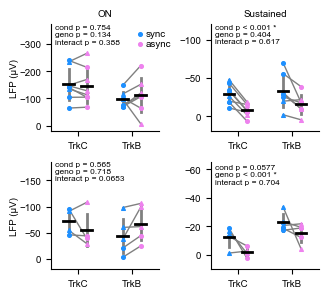

In [9]:
### plot layer 4 for S1 FP and S1HP - dots and mean only - by animals - pval
df_plot_list = [mlfp_on_l4_FP, mlfp_sus_l4_FP, mlfp_on_l4_HP, mlfp_sus_l4_HP]
colorpal = {'sync':'dodgerblue', 'async':'violet'}

sync_color = 'dodgerblue'
async_color = 'violet'
mean_color = 'black'
line_color = 'grey'

markersize = 7
x1_TrkC = 1
x2_TrkC = 2
x1_TrkB = 4
x2_TrkB = 5

mwidth = 0.3
star_size = 8
pval_size = 6
mark_male = '^'
mark_female = 'o'

zorder_line = 1
zorder_dots = 7
zorder_mean = 15

fig, ax = plt.subplots(2,2, figsize=(3.3,3))
for i, idf in enumerate(df_plot_list):
    idf['animalID'] = idf['recID'].str[7:11]
    idf_mice = idf.groupby(['animalID','condSync'], as_index=False).agg({'mlfp': 'mean', 'genoGroup': 'first'})

    idf_mice['sex'] = idf_mice['animalID'].map(sex_map)

    idf_TrkC = idf_mice[idf_mice['genoGroup'].isin(['TrkC','TrkC_S1HP'])]
    idf_TrkB = idf_mice[idf_mice['genoGroup'].isin(['TrkB','TrkB_S1HP'])]

    idf_mice_TrkC_sync = idf_TrkC[idf_TrkC['condSync']=='sync']
    idf_mice_TrkB_sync = idf_TrkB[idf_TrkB['condSync']=='sync']

    females_TrkC = np.where(idf_mice_TrkC_sync['sex'] == 'Female')[0] # idx of which are females
    males_TrkC = np.where(idf_mice_TrkC_sync['sex'] == 'Male')[0] # idx of which are males
    females_TrkB = np.where(idf_mice_TrkB_sync['sex'] == 'Female')[0] # idx of which are females
    males_TrkB = np.where(idf_mice_TrkB_sync['sex'] == 'Male')[0] # idx of which are males

    sync_TrkC_array = np.array(idf_TrkC[idf_TrkC['condSync']=='sync']['mlfp'])
    async_TrkC_array = np.array(idf_TrkC[idf_TrkC['condSync']=='async']['mlfp'])
    sync_TrkB_array = np.array(idf_TrkB[idf_TrkB['condSync']=='sync']['mlfp'])
    async_TrkB_array = np.array(idf_TrkB[idf_TrkB['condSync']=='async']['mlfp'])

    x1_TrkC_array = np.repeat(x1_TrkC, len(sync_TrkC_array))
    x2_TrkC_array = np.repeat(x2_TrkC, len(sync_TrkC_array))

    x1_TrkB_array = np.repeat(x1_TrkB, len(sync_TrkB_array))
    x2_TrkB_array = np.repeat(x2_TrkB, len(sync_TrkB_array))

    ax[i//2, i%2].plot([x1_TrkC_array,x2_TrkC_array], [sync_TrkC_array,async_TrkC_array],c=line_color,lw=1,zorder=zorder_line)
    ax[i//2, i%2].plot([x1_TrkB_array,x2_TrkB_array], [sync_TrkB_array,async_TrkB_array],c=line_color,lw=1,zorder=zorder_line)

    ax[i//2, i%2].scatter(x1_TrkC_array[females_TrkC],sync_TrkC_array[females_TrkC],s=markersize,marker=mark_female,c=sync_color,zorder=zorder_dots,label='sync')
    ax[i//2, i%2].scatter(x1_TrkC_array[males_TrkC],sync_TrkC_array[males_TrkC],s=markersize,marker=mark_male,c=sync_color,zorder=zorder_dots)
    ax[i//2, i%2].scatter(x2_TrkC_array[females_TrkC],async_TrkC_array[females_TrkC],s=markersize,marker=mark_female,c=async_color,zorder=zorder_dots,label='async')
    ax[i//2, i%2].scatter(x2_TrkC_array[males_TrkC],async_TrkC_array[males_TrkC],s=markersize,marker=mark_male,c=async_color,zorder=zorder_dots)
    ax[i//2, i%2].scatter(x1_TrkB_array[females_TrkB],sync_TrkB_array[females_TrkB],s=markersize,marker=mark_female,c=sync_color,zorder=zorder_dots)
    ax[i//2, i%2].scatter(x1_TrkB_array[males_TrkB],sync_TrkB_array[males_TrkB],s=markersize,marker=mark_male,c=sync_color,zorder=zorder_dots)
    ax[i//2, i%2].scatter(x2_TrkB_array[females_TrkB],async_TrkB_array[females_TrkB],s=markersize,marker=mark_female,c=async_color,zorder=zorder_dots)
    ax[i//2, i%2].scatter(x2_TrkB_array[males_TrkB],async_TrkB_array[males_TrkB],s=markersize,marker=mark_male,c=async_color,zorder=zorder_dots)

    ax[i//2, i%2].plot([x1_TrkC-mwidth,x1_TrkC+mwidth], [np.mean(sync_TrkC_array),np.mean(sync_TrkC_array)],c=mean_color,lw=2,zorder=zorder_mean)
    ax[i//2, i%2].plot([x2_TrkC-mwidth,x2_TrkC+mwidth], [np.mean(async_TrkC_array),np.mean(async_TrkC_array)],c=mean_color,lw=2,zorder=zorder_mean)

    ax[i//2, i%2].plot([x1_TrkB-mwidth,x1_TrkB+mwidth], [np.mean(sync_TrkB_array),np.mean(sync_TrkB_array)],c=mean_color,lw=2,zorder=zorder_mean)
    ax[i//2, i%2].plot([x2_TrkB-mwidth,x2_TrkB+mwidth], [np.mean(async_TrkB_array),np.mean(async_TrkB_array)],c=mean_color,lw=2,zorder=zorder_mean)

    ax[i//2, i%2].plot([x1_TrkC,x1_TrkC], [np.mean(sync_TrkC_array)-np.std(sync_TrkC_array),np.mean(sync_TrkC_array)+np.std(sync_TrkC_array)],c=line_color,lw=2,zorder=zorder_line)
    ax[i//2, i%2].plot([x2_TrkC,x2_TrkC], [np.mean(async_TrkC_array)-np.std(async_TrkC_array),np.mean(async_TrkC_array)+np.std(async_TrkC_array)],c=line_color,lw=2,zorder=zorder_line)

    ax[i//2, i%2].plot([x1_TrkB,x1_TrkB], [np.mean(sync_TrkB_array)-np.std(sync_TrkB_array),np.mean(sync_TrkB_array)+np.std(sync_TrkB_array)],c=line_color,lw=2,zorder=zorder_line)
    ax[i//2, i%2].plot([x2_TrkB,x2_TrkB], [np.mean(async_TrkB_array)-np.std(async_TrkB_array),np.mean(async_TrkB_array)+np.std(async_TrkB_array)],c=line_color,lw=2,zorder=zorder_line)

for i in range(4):
    # ax[i//2, i%2].invert_yaxis()
    ax[i//2, i%2].spines['top'].set_visible(False)
    ax[i//2, i%2].spines['right'].set_visible(False)

    ax[i//2, i%2].set_xlim([0,6])
    ax[i//2, i%2].set_xticks([(x1_TrkC+x2_TrkC)/2,(x1_TrkB+x2_TrkB)/2])
    ax[i//2, i%2].set_xticklabels(['TrkC','TrkB'])

for i in [0,2]:
    ax[i//2, i%2].set_ylabel('LFP (\u03BCV)', labelpad=0)

ax[0,0].set_title('ON',fontsize=7)
ax[0,1].set_title('Sustained',fontsize=7)

ax[0,0].legend(borderpad=0,      # Fractional whitespace inside the legend border
    labelspacing=0.1,   # Vertical space between entries
    handlelength=0.7,   # Length of the legend handles (lines/markers)
    handletextpad=0.2,  # Pad between handle and text
    columnspacing=0.5,  # Spacing between columns (if ncol > 1),
    loc = 'upper left',
    bbox_to_anchor = [0.75,1],
    frameon=False)

ax[0,0].set_ylim([-370,20])
ax[0,1].set_ylim([-120,20])
ax[1,0].set_ylim([-185,20])
ax[1,1].set_ylim([-65,10])

### add p values from anova
ax[0,0].text(x=0.25, y=-300, s='cond p = 0.754\ngeno p = 0.134\ninteract p = 0.388', size=pval_size,ha='left')
ax[0,1].text(x=0.25, y=-95, s='cond p < 0.001 *\ngeno p = 0.404\ninteract p = 0.617', size=pval_size,ha='left')
ax[1,0].text(x=0.25, y=-150, s='cond p = 0.565\ngeno p = 0.718\ninteract p = 0.0653', size=pval_size,ha='left')
ax[1,1].text(x=0.25, y=-50, s='cond p = 0.0577\ngeno p < 0.001 *\ninteract p = 0.704', size=pval_size,ha='left')

for i in range(4):
    ax[i//2, i%2].invert_yaxis()
plt.tight_layout()

# plt.savefig(r"N:\Liu_Wanyi\TrkC_figures2\Fig7B_lfp_pval_260421.pdf",dpi=600,bbox_inches='tight',transparent=True)

plt.show()